### 가장 단순한 버전이다. DEM은 사용하지 않고 그냥 48채널의 이미지 처럼 다룬다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### dataset 객체를 수정하여 큰 이미지에서 알아서 슬라이싱해서 가져오도록 바꾼다.

In [3]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_path, label_file, patch_size=3, transform=None):
        """
        Args:
            large_tif_path (str): 큰 TIFF 파일 경로.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 (x_pos, y_pos, label 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (기본값: 3).
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        self.large_tif_path = large_tif_path
        self.label_df = pd.read_csv(label_file)
        self.patch_size = patch_size
        self.transform = transform

        # 큰 tif 이미지 로드
        self.large_image = tiff.imread(large_tif_path)
        self.image_height, self.image_width = self.large_image.shape[:2]

        # 데이터프레임에서 좌표와 라벨 정보 추출
        self.x_positions = self.label_df['x_pos'].values
        self.y_positions = self.label_df['y_pos'].values
        self.labels = self.label_df['label'].values

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 좌상단 좌표와 라벨 가져오기
        x, y = self.x_positions[idx], self.y_positions[idx]
        label = self.labels[idx]

        # 범위 검사
        if x < 0 or y < 0 or x + self.patch_size > self.image_width or y + self.patch_size > self.image_height:
            raise ValueError(f"Patch at position (x={x}, y={y}) exceeds image bounds.")

        # 이미지 슬라이싱
        patch = self.large_image[y:y+self.patch_size, x:x+self.patch_size]

        # 전처리
        if self.transform:
            patch = self.transform(patch)

        return patch, label


In [4]:
# 이미지 전처리 (Naive)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
])

dataset = TiffDataset(
    large_tif_path = r"C:\Users\taebin\Desktop\my_study\capstone_design\data2\원천 데이터\jiri\planet_1.tif",
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data2\라벨링 데이터\jiri\label_mapping_sampled_1.csv",
    transform=transform
)

# 학습과 검증 데이터셋 나누기
train_dataset, val_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### resnet과 같은 구조의 모델

In [5]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class ResNetLike(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNetLike, self).__init__()
        self.in_channels = 64
        
        # 48 채널 입력을 처리할 Conv Layer
        self.conv1 = nn.Conv2d(48, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=1)
        self.layer3 = self._make_layer(256, 2, stride=1)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

### train 함수, evaluate 함수

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    no_improve_count = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation loop
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            no_improve_count = 0
        else:
            no_improve_count += 1

        # Early stopping
        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break

    # Load the best model state
    if best_model_state:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses


In [7]:
def evaluate_model_with_cm(model, val_loader, num_classes=8):
    model.eval()
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        # tqdm으로 진행 상황 표시
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)  # device로 데이터 이동

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  # 실제 라벨
            all_predictions.extend(predicted.cpu().numpy())  # 예측된 라벨

    # 라벨 범위 설정
    labels = np.arange(0, num_classes)

    # Confusion matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=labels)

    # Confusion matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    # Classification report 계산
    report = classification_report(all_labels, all_predictions, labels=labels, target_names=[str(label) for label in labels])
    
    print("Classification Report:")
    print(report)

### 모델 훈련

In [8]:
model = ResNetLike(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

100%|██████████| 1519/1519 [02:19<00:00, 10.86it/s]


Epoch [1/50], Train Loss: 0.6321, Train Accuracy: 77.07%, Val Loss: 0.5763, Val Accuracy: 78.24%


100%|██████████| 1519/1519 [02:21<00:00, 10.72it/s]


Epoch [2/50], Train Loss: 0.4983, Train Accuracy: 81.98%, Val Loss: 0.4943, Val Accuracy: 83.08%


100%|██████████| 1519/1519 [02:21<00:00, 10.76it/s]


...

100%|██████████| 1519/1519 [02:19<00:00, 10.92it/s]


Epoch [49/50], Train Loss: 0.1307, Train Accuracy: 95.12%, Val Loss: 0.2068, Val Accuracy: 92.69%


100%|██████████| 1519/1519 [02:20<00:00, 10.80it/s]


Epoch [50/50], Train Loss: 0.1318, Train Accuracy: 95.06%, Val Loss: 0.2483, Val Accuracy: 91.46%


Evaluation Progress: 100%|██████████| 380/380 [00:06<00:00, 60.25it/s]


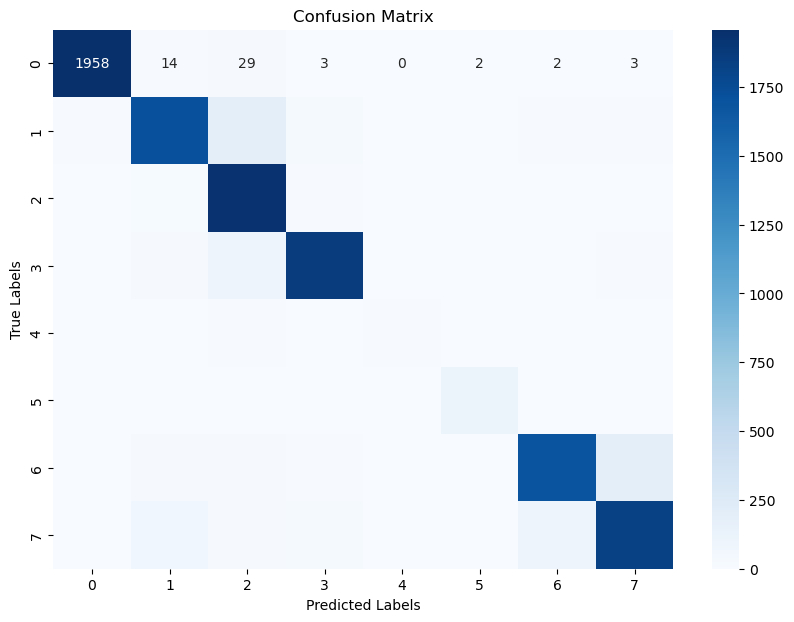

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2011
           1       0.91      0.87      0.89      1972
           2       0.83      0.98      0.90      1970
           3       0.95      0.92      0.94      2016
           4       1.00      0.35      0.52        31
           5       0.93      0.86      0.90       131
           6       0.94      0.86      0.90      1959
           7       0.89      0.89      0.89      2058

    accuracy                           0.91     12148
   macro avg       0.93      0.84      0.86     12148
weighted avg       0.92      0.91      0.91     12148



In [9]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50)
torch.save(model, "naive_50.pth")
evaluate_model_with_cm(model, val_loader, num_classes=8)

### 다른 지역 데이터로 테스트 - jiri2

In [11]:
jiri2_dataset = TiffDataset(
    large_tif_path = r"C:\Users\taebin\Desktop\my_study\capstone_design\data2\원천 데이터\jiri\planet_2.tif",
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data2\라벨링 데이터\jiri\label_mapping_sampled_2.csv",
    transform=transform
)


jiri2_loader = DataLoader(jiri2_dataset, batch_size=32, shuffle=False)

Evaluation Progress: 100%|██████████| 1368/1368 [00:24<00:00, 55.99it/s]


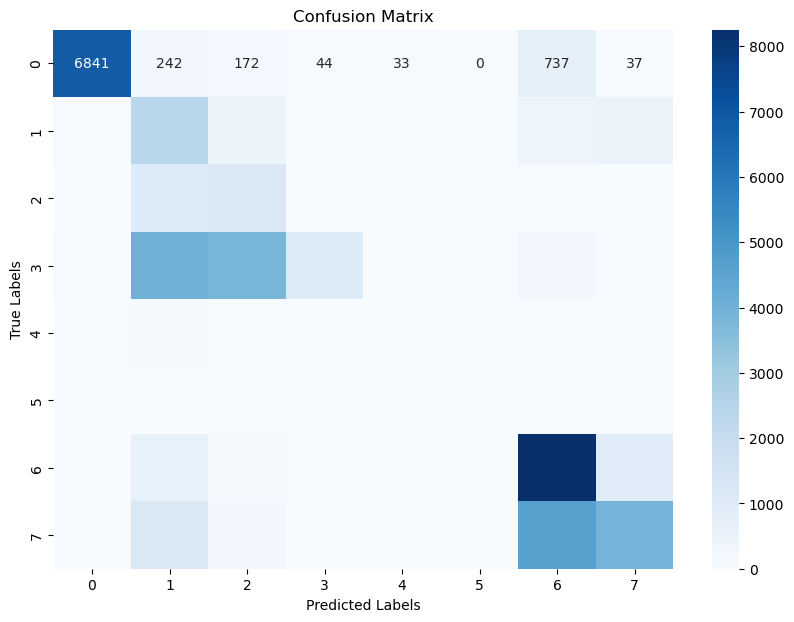

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91      8106
           1       0.24      0.62      0.35      3844
           2       0.20      0.51      0.29      2388
           3       0.92      0.12      0.21      9269
           4       0.00      0.00      0.00       162
           5       0.00      0.00      0.00         0
           6       0.58      0.83      0.68     10000
           7       0.72      0.39      0.51     10000

    accuracy                           0.54     43769
   macro avg       0.46      0.41      0.37     43769
weighted avg       0.71      0.54      0.53     43769



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
evaluate_model_with_cm(model, jiri2_loader, num_classes=8)

### 다른 지역의 데이터로 테스트 - sobaek

In [13]:
sobaek_dataset = TiffDataset(
    large_tif_path = r"C:\Users\taebin\Desktop\my_study\capstone_design\data2\원천 데이터\sobaek\planet.tif",
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data2\라벨링 데이터\sobaek\label_mapping_sampled.csv",
    transform=transform
)


sobaek_loader = DataLoader(sobaek_dataset, batch_size=32, shuffle=False)

Evaluation Progress: 100%|██████████| 1635/1635 [00:28<00:00, 56.95it/s]


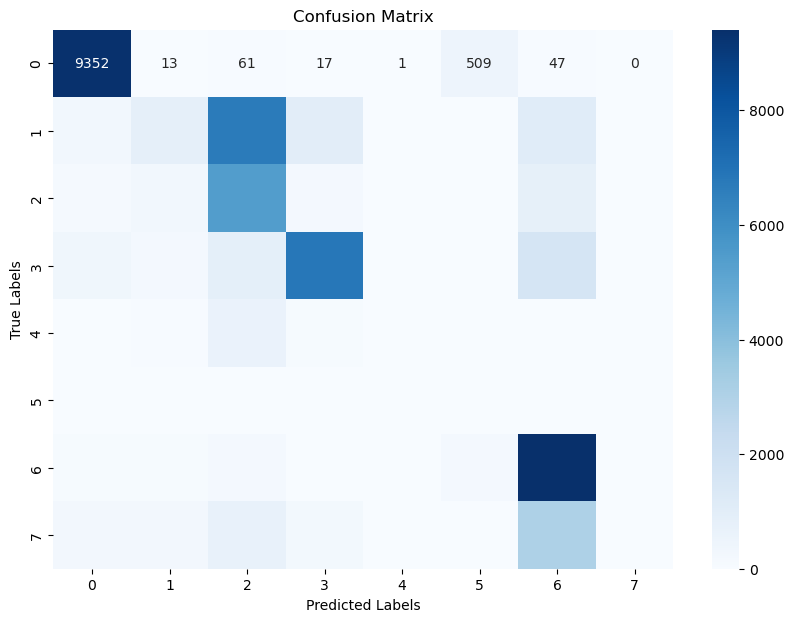

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     10000
           1       0.46      0.09      0.14     10000
           2       0.37      0.78      0.50      6942
           3       0.82      0.68      0.74     10000
           4       0.00      0.00      0.00       800
           5       0.00      0.00      0.00         0
           6       0.58      0.94      0.72     10000
           7       0.11      0.00      0.00      4573

    accuracy                           0.61     52315
   macro avg       0.40      0.43      0.38     52315
weighted avg       0.58      0.61      0.55     52315



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
evaluate_model_with_cm(model, sobaek_loader, num_classes=8)